# 2장 2강: 퍼널 분석 — 전환율·이탈률 측정 원리 — 실습문제

## 실습 목표

- Ravenstack의 구독 여정을 순차적인 퍼널 단계로 정의할 수 있다.
- 이벤트 횟수와 고유 구독 수의 차이를 설명할 수 있다.
- 단계별 전환율과 이탈률을 계산할 수 있다.
- 막대형 퍼널을 시각화하고 이탈이 집중된 구간을 찾을 수 있다.
- 세그먼트별 퍼널을 비교하고 개선 가설을 제안할 수 있다.

## 실습 환경 / 데이터

- Python
- pandas
- matplotlib
- `ravenstack_subscriptions.csv`
- `ravenstack_feature_usage.csv`

이번 실습에서는 Ravenstack의 구독 여정을 다음과 같이 단순화합니다.

| 순서 | 퍼널 단계 | 집계 기준 |
|---:|---|---|
| 1 | 구독 시작 | `subscriptions`에 존재하는 고유 구독 |
| 2 | 기능 사용 | 기능 사용 기록이 한 번 이상 있는 구독 |
| 3 | 유료 구독 | 기능 사용 구독 중 `is_trial == False`인 구독 |
| 4 | 현재 유료 유지 | 이전 단계 구독 중 `end_date`가 비어 있는 구독 |

> 이 퍼널은 전환율 계산 원리를 익히기 위한 학습용 정의입니다. `is_trial`은 실제 유료 전환 시각을 기록한 이벤트가 아니므로 실제 전환 소요 시간이나 행동 순서를 완전히 재구성할 수는 없습니다.

## 실습 준비

1. 필요한 라이브러리를 불러오세요.
2. 두 CSV 파일을 각각 `subscriptions`, `feature_usage`에 불러오세요.
3. 각 데이터의 행과 열 개수, 상위 5개 행을 확인하세요.
4. 분석 대상 컬럼의 자료형과 결측치 개수를 확인하세요.
5. `start_date`, `end_date`, `usage_date`를 날짜형으로 변환하세요.
6. 구독 ID의 고유 개수와 기능 사용 이벤트 행 수를 확인하세요.
7. `usage_id`의 중복 개수를 확인하고, 중복 ID를 바로 삭제하면 안 되는 이유를 생각해보세요.

In [1]:
# 실습 준비 코드를 작성하세요.
# 1. 라이브러리 불러오기
import pandas as pd
import matplotlib.pyplot as plt

# 2. CSV 불러오기
subscriptions = pd.read_csv("ravenstack_subscriptions.csv")
feature_usage = pd.read_csv("ravenstack_feature_usage.csv")

# 3. 행/열 개수, 상위 5행 확인
print("subscriptions shape:", subscriptions.shape)
print(subscriptions.head())
print("\nfeature_usage shape:", feature_usage.shape)
print(feature_usage.head())

# 4. 자료형, 결측치 개수 확인
print("\nsubscriptions dtypes:\n", subscriptions.dtypes)
print("subscriptions 결측치:\n", subscriptions.isna().sum())
print("\nfeature_usage dtypes:\n", feature_usage.dtypes)
print("feature_usage 결측치:\n", feature_usage.isna().sum())

# 5. 날짜형 변환
subscriptions["start_date"] = pd.to_datetime(subscriptions["start_date"])
subscriptions["end_date"] = pd.to_datetime(subscriptions["end_date"])
feature_usage["usage_date"] = pd.to_datetime(feature_usage["usage_date"])

# 6. 구독 ID 고유 개수, 기능 사용 이벤트 행 수
print("\n구독 ID 고유 개수:", subscriptions["subscription_id"].nunique())
print("기능 사용 이벤트 행 수:", len(feature_usage))

# 7. usage_id 중복 개수 확인
dup_count = feature_usage["usage_id"].duplicated().sum()
print("\nusage_id 중복 개수:", dup_count)

subscriptions shape: (5000, 14)
  subscription_id account_id  start_date    end_date   plan_tier  seats  \
0        S-8cec59   A-3c1a3f  2023-12-23  2024-04-12  Enterprise     14   
1        S-0f6f44   A-9b9fe9  2024-06-11         NaN         Pro     17   
2        S-51c0d1   A-659280  2024-11-25         NaN  Enterprise     62   
3        S-f81687   A-e7a1e2  2024-11-23  2024-12-13  Enterprise      5   
4        S-cff5a2   A-ba6516  2024-01-10         NaN  Enterprise     27   

   mrr_amount  arr_amount  is_trial  upgrade_flag  downgrade_flag  churn_flag  \
0        2786       33432     False         False           False        True   
1         833        9996     False         False           False       False   
2           0           0      True          True           False       False   
3         995       11940     False         False           False        True   
4        5373       64476     False         False           False       False   

  billing_frequency  auto_rene

---

## 필수 1. 전체 구독 퍼널의 전환율과 이탈률 계산하기

### 문제 1-1. Ravenstack 구독은 어느 구간에서 가장 많이 이탈하는가?

#### 문제 설명

전체 Ravenstack 구독을 대상으로 네 단계의 고유 구독 수를 계산하고, 각 구간의 전환율과 이탈률을 구하세요.

각 단계는 반드시 앞 단계를 통과한 구독만 포함해야 합니다. 예를 들어 유료 구독 단계는 전체 유료 구독이 아니라 **기능 사용 단계에 포함되면서 유료인 구독**으로 계산합니다.

#### 요구사항

1. 전체 구독 ID를 `started_ids`로 만드세요.
2. 기능 사용 기록이 있는 구독 ID와 `started_ids`의 교집합을 `used_ids`로 만드세요.
3. `used_ids`와 체험이 아닌 구독 ID의 교집합을 `paid_ids`로 만드세요.
4. `paid_ids`와 종료일이 비어 있는 구독 ID의 교집합을 `retained_paid_ids`로 만드세요.
5. 단계명과 고유 구독 수를 사용하여 `funnel` 데이터프레임을 만드세요.
6. 다음 식으로 구간 전환율과 이탈률을 계산하세요.
   - 전환율 = 현재 단계 구독 수 ÷ 이전 단계 구독 수
   - 이탈률 = 1 - 전환율
7. 각 구간의 이탈 구독 수도 계산하세요.
8. 단계별 구독 수를 막대그래프로 시각화하세요.
9. 전환율이 가장 낮은 구간을 찾고 개선 가설을 한 가지 제안하세요.

#### 해석 질문

**Q1.** 기능 사용 이벤트 행 수 대신 고유 구독 수를 사용해야 하는 이유는 무엇인가요?  
**Q2.** 전환율이 가장 낮고 이탈 구독 수가 가장 많은 구간은 어디인가요?  
**Q3.** 전환율과 이탈률을 더하면 얼마인가요?  
**Q4.** 낮은 전환율만으로 실제 이탈 원인을 확정할 수 있나요?

#### 제출 결과

- 단계별 고유 구독 집합
- `funnel` 데이터프레임
- 전환율·이탈률·이탈 구독 수
- 막대형 퍼널
- 이탈 집중 구간과 개선 가설
- Q1~Q4 답변

      stage  count  conversion_rate  churn_rate  churned_count
0     전체 구독   5000              NaN         NaN            NaN
1     기능 사용   4967         0.993400    0.006600           33.0
2     유료 구독   4193         0.844172    0.155828          774.0
3  활성 유료 구독   3788         0.903410    0.096590          405.0


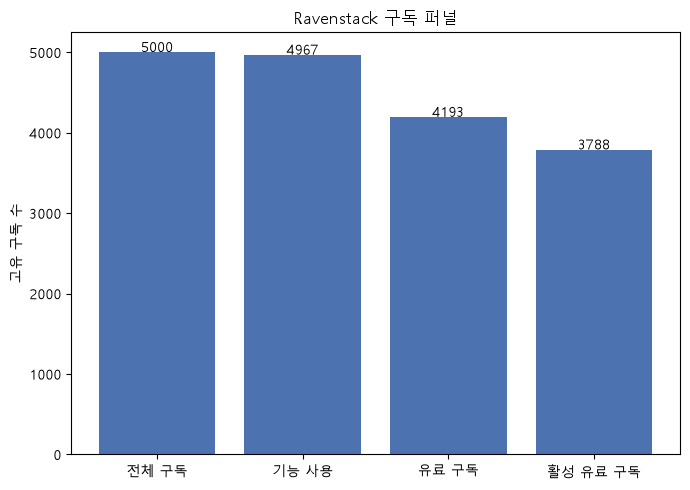

In [7]:
# 필수 1 코드를 작성하세요.

plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False
# 1. 전체 구독 ID
started_ids = set(subscriptions["subscription_id"])

# 2. 기능 사용 기록 있는 구독 ID ∩ started_ids
used_ids = set(feature_usage["subscription_id"]) & started_ids

# 3. used_ids ∩ 체험 아닌 구독 ID
non_trial_ids = set(subscriptions.loc[subscriptions["is_trial"] == False, "subscription_id"])
paid_ids = used_ids & non_trial_ids

# 4. paid_ids ∩ 종료일 비어있는 구독 ID
active_ids = set(subscriptions.loc[subscriptions["end_date"].isna(), "subscription_id"])
retained_paid_ids = paid_ids & active_ids

# 5. funnel 데이터프레임
funnel = pd.DataFrame({
    "stage": ["전체 구독", "기능 사용", "유료 구독", "활성 유료 구독"],
    "count": [len(started_ids), len(used_ids), len(paid_ids), len(retained_paid_ids)],
})

# 6. 전환율/이탈률
funnel["conversion_rate"] = funnel["count"] / funnel["count"].shift(1)
funnel["churn_rate"] = 1 - funnel["conversion_rate"]

# 7. 이탈 구독 수
funnel["churned_count"] = funnel["count"].shift(1) - funnel["count"]

print(funnel)

# 8. 막대그래프
plt.figure(figsize=(7,5))
plt.bar(funnel["stage"], funnel["count"], color="#4C72B0")
plt.title("Ravenstack 구독 퍼널")
plt.ylabel("고유 구독 수")
for i, v in enumerate(funnel["count"]):
    plt.text(i, v+5, str(v), ha="center")
plt.tight_layout()
plt.show()

### 필수 1 답변 작성란

**Q1.** 기능 사용 이벤트 행 수 대신 고유 구독 수를 사용해야 하는 이유는 무엇인가요?  
-> `같은 구독에서 기능 사용 이벤트가 여러 번 발생할 수 있다.`  
-> `중복 계산이 될 위험성이 있다.` 

**Q2.** 전환율이 가장 낮고 이탈 구독 수가 가장 많은 구간은 어디인가요?  
-> `기능 사용 -> 유료 구독 구간, 전환율은 약 84.42%, 이탈 구독 수는 774개`

**Q3.** 전환율과 이탈률을 더하면 얼마인가요?  
-> `100% -> 이탈률 = 1 - 전환율`

**Q4.** 낮은 전환율만으로 실제 이탈 원인을 확정할 수 있나요?  
-> `없다. 퍼널은 사용자가 많이 줄어든 위치를 보여주지만 가격, 성능, 기능 부족 등 어떤 이유로 줄었는지 원인 파악이 추가적으로 필요하다.`

---

## 필수 2. 요금제별 퍼널 비교하기

### 문제 2-1. 요금제에 따라 이탈 구간이 다른가?

#### 문제 설명

`Basic`, `Pro`, `Enterprise` 요금제별로 동일한 퍼널을 계산하고 구간 전환율을 비교하세요. 그룹별 비교를 통해 특정 요금제에 문제가 집중되어 있는지 확인합니다.

#### 요구사항

1. 요금제별 퍼널을 계산하는 함수 `calculate_segment_funnel()`을 작성하세요.
2. 함수는 필수 1과 동일한 네 단계의 고유 구독 수와 구간 전환율을 반환해야 합니다.
3. 세 요금제의 결과를 결합하여 `plan_funnel`을 만드세요.
4. 첫 단계를 제외한 구간별 전환율을 요금제별 막대그래프로 시각화하세요.
5. 모든 요금제와 구간의 조합 중 전환율이 가장 낮은 조합을 찾으세요.
6. 해당 요금제와 구간을 우선 점검 대상으로 정하고 개선 가설을 한 가지 제안하세요.
7. 요금제별 차이가 크지 않을 경우 해석에서 그 사실도 언급하세요.

#### 해석 질문

**Q1.** 전환율이 가장 낮은 요금제와 구간의 조합은 무엇인가요?  
**Q2.** 요금제별 퍼널 비교가 전체 퍼널만 보는 것보다 유용한 이유는 무엇인가요?  
**Q3.** 관찰된 요금제별 차이는 큰 편인가요?  
**Q4.** 개선 가설을 확인하기 위해 어떤 데이터를 추가로 살펴볼 수 있나요?

#### 제출 결과

- 요금제별 퍼널 계산 함수
- `plan_funnel` 결과
- 요금제별 전환율 그래프
- 우선 점검 대상과 개선 가설
- Q1~Q4 답변

     plan_tier     stage  count  conversion_rate
0        Basic     전체 구독   1602              NaN
1        Basic     기능 사용   1588         0.991261
2        Basic     유료 구독   1343         0.845718
3        Basic  활성 유료 구독   1217         0.906180
4          Pro     전체 구독   1675              NaN
5          Pro     기능 사용   1665         0.994030
6          Pro     유료 구독   1407         0.845045
7          Pro  활성 유료 구독   1273         0.904762
8   Enterprise     전체 구독   1723              NaN
9   Enterprise     기능 사용   1714         0.994777
10  Enterprise     유료 구독   1443         0.841890
11  Enterprise  활성 유료 구독   1298         0.899515


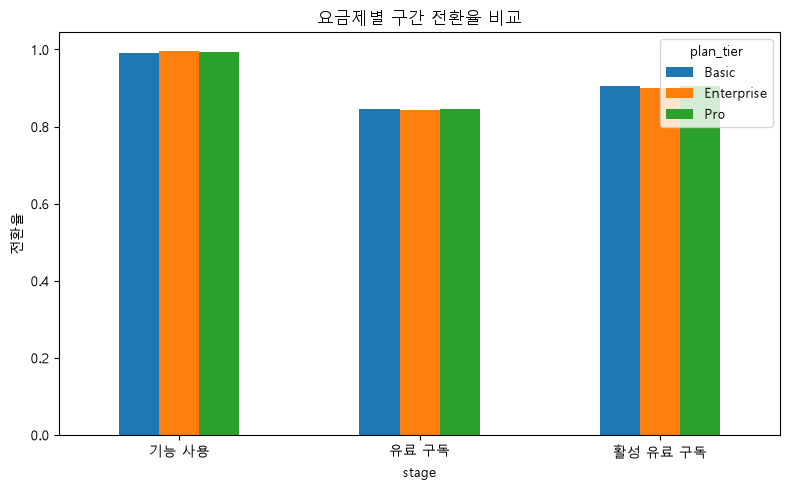


전환율 가장 낮은 조합: Enterprise - 유료 구독 (84.19%)


In [8]:
# 필수 2 코드를 작성하세요.
# 1~2. 요금제별 퍼널 계산 함수
def calculate_segment_funnel(plan_tier_name):
    subs_seg = subscriptions[subscriptions["plan_tier"] == plan_tier_name]

    started_ids = set(subs_seg["subscription_id"])
    used_ids = set(feature_usage["subscription_id"]) & started_ids
    non_trial_ids = set(subs_seg.loc[subs_seg["is_trial"] == False, "subscription_id"])
    paid_ids = used_ids & non_trial_ids
    active_ids = set(subs_seg.loc[subs_seg["end_date"].isna(), "subscription_id"])
    retained_paid_ids = paid_ids & active_ids

    seg_funnel = pd.DataFrame({
        "plan_tier": plan_tier_name,
        "stage": ["전체 구독", "기능 사용", "유료 구독", "활성 유료 구독"],
        "count": [len(started_ids), len(used_ids), len(paid_ids), len(retained_paid_ids)],
    })
    seg_funnel["conversion_rate"] = seg_funnel["count"] / seg_funnel["count"].shift(1)
    return seg_funnel

# 3. 세 요금제 결합
plan_funnel = pd.concat(
    [calculate_segment_funnel(p) for p in ["Basic", "Pro", "Enterprise"]],
    ignore_index=True
)
print(plan_funnel)

# 4. 구간별 전환율 요금제별 막대그래프 (첫 단계 제외)
plot_df = plan_funnel[plan_funnel["stage"] != "전체 구독"]
pivot = plot_df.pivot(index="stage", columns="plan_tier", values="conversion_rate")
pivot = pivot.reindex(["기능 사용", "유료 구독", "활성 유료 구독"])

pivot.plot(kind="bar", figsize=(8,5))
plt.title("요금제별 구간 전환율 비교")
plt.ylabel("전환율")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 5. 전환율 가장 낮은 조합 (첫 단계 제외)
lowest_row = plot_df.loc[plot_df["conversion_rate"].idxmin()]
print("\n전환율 가장 낮은 조합:", lowest_row["plan_tier"], "-", lowest_row["stage"],
      f"({lowest_row['conversion_rate']:.2%})")

### 필수 2 답변 작성란

**Q1.** 전환율이 가장 낮은 요금제와 구간의 조합은 무엇인가요?  
-> `Enterprise 요금제의 기능 사용 -> 유료 구독 구간, 전환율은 84.19%`

**Q2.** 요금제별 퍼널 비교가 전체 퍼널만 보는 것보다 유용한 이유는 무엇인가요?  
-> `전체 결과에서는 쉽게 볼 수 없는 특정 요금제의 상대적으로 낮은 구간을 찾을 수 있어 개선 대상을 더 구체적으로 정할 수 있음`

**Q3.** 관찰된 요금제별 차이는 큰 편인가요?  
-> `아닙니다. 기능 사용에서 유료 구독으로 이어지는 전환율은 세 요금제 모두 약 84% 정도로 차이가 적다.`

**Q4.** 개선 가설을 확인하기 위해 어떤 데이터를 추가로 살펴볼 수 있나요?  
-> `체험 종료, 이탈 사유, 고객문의 데이터`

---

## 과제 1. 평가 문항 기반 독립 과제

### 문제 3-1. 결제 주기별 퍼널 비교하기

#### 문제 설명

월간 결제 구독과 연간 결제 구독의 퍼널을 비교하여 상대적으로 전환율이 낮은 그룹과 구간을 찾으세요.

> 이 과제는 필수 2에서 만든 함수와 분석 절차를 `billing_frequency`에 동일하게 적용하는 문제입니다.

#### 요구사항

1. `calculate_segment_funnel()`을 사용하여 `monthly`, `annual`의 퍼널을 계산하세요.
2. 두 결과를 결합하여 `billing_funnel`을 만드세요.
3. 첫 단계를 제외한 구간 전환율을 결제 주기별 막대그래프로 시각화하세요.
4. 모든 결제 주기와 구간의 조합 중 전환율이 가장 낮은 조합을 찾으세요.
5. 해당 그룹과 구간에 대한 개선 가설을 한 가지 제안하세요.
6. 퍼널 결과만으로 원인을 확정할 수 없는 이유와 추가 확인할 데이터를 설명하세요.

#### 해석 질문

**Q1.** 전환율이 가장 낮은 결제 주기와 구간의 조합은 무엇인가요?  
**Q2.** 해당 구간의 전환율과 이탈률은 얼마인가요?  
**Q3.** 이 결과만으로 결제 주기가 이탈의 원인이라고 말할 수 있나요?

#### 제출 결과

- `billing_funnel` 결과
- 결제 주기별 전환율 그래프
- 우선 점검 대상과 개선 가설
- 분석의 한계와 추가 확인 데이터
- Q1~Q3 답변

  billing_frequency     stage  count  conversion_rate  churn_rate
0           monthly     전체 구독   2539              NaN         NaN
1           monthly     기능 사용   2520         0.992517    0.007483
2           monthly     유료 구독   2120         0.841270    0.158730
3           monthly  활성 유료 구독   1930         0.910377    0.089623
4            annual     전체 구독   2461              NaN         NaN
5            annual     기능 사용   2447         0.994311    0.005689
6            annual     유료 구독   2073         0.847160    0.152840
7            annual  활성 유료 구독   1858         0.896286    0.103714


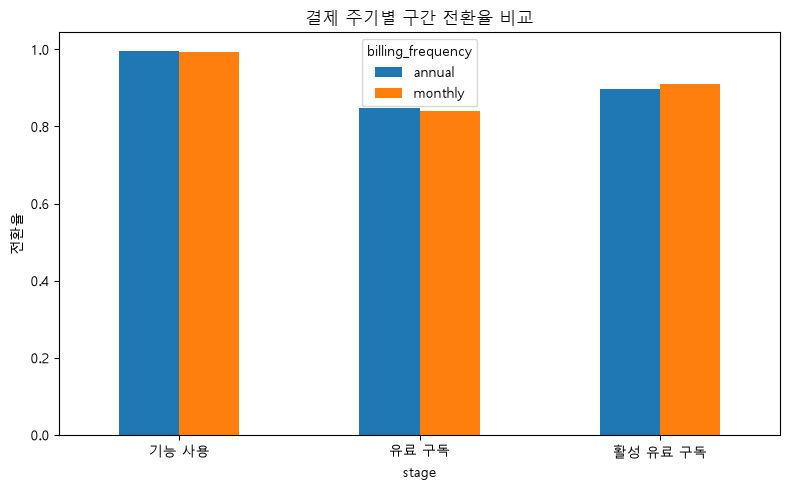


전환율 가장 낮은 조합: monthly - 유료 구독 (전환율=84.13%, 이탈률=15.87%)


In [10]:
# 과제 1 코드를 작성하세요.
def calculate_segment_funnel(column, value):
    subs_seg = subscriptions[subscriptions[column] == value]

    started_ids = set(subs_seg["subscription_id"])
    used_ids = set(feature_usage["subscription_id"]) & started_ids
    non_trial_ids = set(subs_seg.loc[subs_seg["is_trial"] == False, "subscription_id"])
    paid_ids = used_ids & non_trial_ids
    active_ids = set(subs_seg.loc[subs_seg["end_date"].isna(), "subscription_id"])
    retained_paid_ids = paid_ids & active_ids

    seg_funnel = pd.DataFrame({
        column: value,
        "stage": ["전체 구독", "기능 사용", "유료 구독", "활성 유료 구독"],
        "count": [len(started_ids), len(used_ids), len(paid_ids), len(retained_paid_ids)],
    })
    seg_funnel["conversion_rate"] = seg_funnel["count"] / seg_funnel["count"].shift(1)
    seg_funnel["churn_rate"] = 1 - seg_funnel["conversion_rate"]
    return seg_funnel

# 1~2. monthly, annual 퍼널 계산 + 결합
billing_funnel = pd.concat(
    [calculate_segment_funnel("billing_frequency", b) for b in ["monthly", "annual"]],
    ignore_index=True
)
print(billing_funnel)

# 3. 구간별 전환율 결제주기별 막대그래프 (첫 단계 제외)
plot_df = billing_funnel[billing_funnel["stage"] != "전체 구독"]
pivot = plot_df.pivot(index="stage", columns="billing_frequency", values="conversion_rate")
pivot = pivot.reindex(["기능 사용", "유료 구독", "활성 유료 구독"])

pivot.plot(kind="bar", figsize=(8,5))
plt.title("결제 주기별 구간 전환율 비교")
plt.ylabel("전환율")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 4. 전환율 가장 낮은 조합
lowest_row = plot_df.loc[plot_df["conversion_rate"].idxmin()]
print("\n전환율 가장 낮은 조합:", lowest_row["billing_frequency"], "-", lowest_row["stage"],
      f"(전환율={lowest_row['conversion_rate']:.2%}, 이탈률={lowest_row['churn_rate']:.2%})")

### 과제 1 답변 작성란

**Q1.** 전환율이 가장 낮은 결제 주기와 구간의 조합은 무엇인가요?    
-> `monthly - 유료구독`

**Q2.** 해당 구간의 전환율과 이탈률은 얼마인가요?    
-> `전환율 84.13% / 이탈률 15.87%`

**Q3.** 이 결과만으로 결제 주기가 이탈의 원인이라고 말할 수 있나요?  
-> `아니오`  
-> `monthly와 annual 두 그룹 사이에 전환율 차이가 있다는 사실만 보여줄 뿐, 그 차이의 원인이 결제 주기 자체 때문에 발생했다는 인과관계까지 증명해주지는 않음`  

- 우선 점검 대상과 개선 가설  
- `점검 대상: monthly 결제 그룹의 "기능 사용 → 유료 구독" 구간`  
-> 유료 구독 구간은 is_trial == False이기 때문에, 이 구간의 낮은 전환율은 "체험(trial)구독 → 유료로 넘어가지 못하는 비율이 높음을 뜻하여 우선 점검 대상으로 선정. `추가 데이터`로는 결제 주기별 trial 비율(is_trial 분포), 결제 주기별 요금제(plan_tier) 구성비, 트라이얼 시작~종료 기간이나 트라이얼 종료 시점의 유료로 전환시킬 수 있는 영업 유도 여부 등을 확인하여 지금 보이는 전환율 차이가 결제 주기 때문인지 다른 요인 때문인지 추가로 확인해볼 필요가 있음  
- `개선 가설:` monthly 결제 고객 중 체험 비중이 annual보다 상대적으로 높거나, 체험종료 시점에 유료 전환 유도(할인 프로모션 등)가 약해서 이탈이 더 많이 발생하는 것일 수 있음

---

## 실습 마무리

아래 질문에 답하세요.

1. 이번 실습의 퍼널 단계를 어떻게 정의했나요?  
-> `구독 여부 - 기능 사용 여부 - 유료 구독 전환 - 구독 유지(종료 date가 없는)`

2. 단계별 사용자 수 대신 어떤 식별자의 고유 개수를 사용했나요?  
-> `구독자 ID의 고유값을 사용`

3. 전환율과 이탈률은 어떻게 계산했나요?  
-> `현재 단계 구독 수를 이전 단계 구독 수로 나누어 전환율을 계산, 1에서 전환율을 빼서 이탈율을 계산`

4. 전체 퍼널에서 가장 큰 문제가 나타난 구간은 어디였나요?  
-> `기능 -> 유료 구독약 84%의 전환율, 이탈율은 16%`

5. 퍼널 분석 결과와 실제 원인을 왜 구분해야 하나요?  
-> `퍼널은 어느 구간에서 사용자가 줄었는지 보여주지만`  
-> `가격, 기능, 문의 등 어떤 요인이 원인이었는지 직접 알려주지는 않는다.`